In [1]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import scienceplots
import tifffile as tiff

plt.style.use('science')
plt.rcParams["figure.figsize"] = (3.5, 3.5 * ((5**0.5 - 1) / 2)) # 3.5
plt.rcParams["figure.dpi"] = 600
%matplotlib inline

import polars as pl
from polars import Expr, LazyFrame, DataFrame
import numpy as np
from pathlib import Path
from pathlib import Path
from typing import Any
import tifffile
from typing import Dict
from typing import Callable
from boulder_statistics.analysis.quick_calculate import FittingFunction
from boulder_statistics.analysis.data_product_encyclopedia import DataProductEncyclopedia

dp = DataProductEncyclopedia(
    data_products_path=Path(r"C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33\.data_products"))

In [2]:
manual_db = pl.read_parquet(r".database\manual_detection_database.parquet")
auto_db = dp.combined_mask_no_merge.filter(pl.col("face") == "posx").collect()

manual_db

i,j,manual_detect_boulder_id,face
i32,i32,u32,str
7661,5626,7883757,"""posx"""
7661,5627,7883757,"""posx"""
7661,5628,7883757,"""posx"""
7661,5629,7883757,"""posx"""
7661,5630,7883757,"""posx"""
…,…,…,…
40,2454,10549449,"""posx"""
40,2455,10549449,"""posx"""
40,2456,10549449,"""posx"""


In [3]:
auto_db_agg = auto_db.group_by("row_id").agg(pl.len().alias("auto_boulder_size"))
manual_db_agg = manual_db.group_by("manual_detect_boulder_id").agg(pl.len().alias("manual_boulder_size"))

db_intersections = manual_db.join(
    auto_db,
    on=["i", "j"],
    how="inner",
).select("i", "j", "lod_level", "lod_code", "row_id", "manual_detect_boulder_id")

db_intersections

i,j,lod_level,lod_code,row_id,manual_detect_boulder_id
i32,i32,u8,str,u32,u32
64,2480,0,"""""",6,10549449
64,2481,0,"""""",6,10549449
64,2482,0,"""""",6,10549449
64,2483,0,"""""",6,10549449
64,2484,0,"""""",6,10549449
…,…,…,…,…,…
7185,7880,4,"""DDDB""",3870233,6288700
7186,7879,4,"""DDDB""",3870233,6288700
7186,7880,4,"""DDDB""",3870233,6288700


In [4]:
db_intersections_agg = db_intersections.group_by("manual_detect_boulder_id", "row_id").agg(
    pl.len().alias("overlap"),
    pl.col("lod_level").first(),
    pl.col("lod_code").first()
)

db_jaccard = db_intersections_agg.join(
    auto_db_agg,
    on="row_id",
    how="left",
).join(
    manual_db_agg,
    on="manual_detect_boulder_id",
    how="left",
).with_columns(
    (
        pl.col("overlap") / (pl.col("auto_boulder_size") + pl.col("manual_boulder_size") - pl.col("overlap"))
    ).alias("Jaccard_index")
)

db_jaccard

manual_detect_boulder_id,row_id,overlap,lod_level,lod_code,auto_boulder_size,manual_boulder_size,Jaccard_index
u32,u32,u32,u8,str,u32,u32,f64
9522572,2907315,109,1,"""D""",25344,107075,0.000824
7439628,141,12675,0,"""""",15872,12977,0.783665
5505284,750999,209,4,"""ADAA""",209,17330,0.01206
5382605,762606,100,4,"""ADAB""",100,56462,0.001771
3485687,762674,79,4,"""ADAB""",242,56663,0.00139
…,…,…,…,…,…,…,…
15234118,1965637,106,4,"""CAAA""",106,79858,0.001327
15234118,1981023,16,4,"""CAAB""",115,79858,0.0002
13856783,1981168,528,4,"""CAAB""",528,57084,0.00925


In [5]:
db_jaccard_agg = (
    db_jaccard
    .group_by(["lod_level", "manual_detect_boulder_id"])
    .agg(
        pl.all().get(
            pl.col("Jaccard_index").arg_max()
        )
    )
).with_columns(
    (pl.col("manual_boulder_size") // (2 ** (8 - 2 * pl.col("lod_level")))).alias("viewport_size"),
    (pl.col("auto_boulder_size") / pl.col("manual_boulder_size")).alias("area_diff_factor")
)

db_jaccard_agg

lod_level,manual_detect_boulder_id,row_id,overlap,lod_code,auto_boulder_size,manual_boulder_size,Jaccard_index,viewport_size,area_diff_factor
u8,u32,u32,u32,str,u32,u32,f64,u32,f64
1,4110046,19830,4983,"""A""",5504,6481,0.711654,101,0.849252
4,16163384,3759554,112,"""DDBA""",112,34525,0.003244,34525,0.003244
2,1153751,3174725,20773,"""DB""",21792,24539,0.812779,1533,0.888056
4,4697392,3205939,219,"""DBAA""",225,339,0.634783,339,0.663717
0,5545641,92,18474,"""""",19712,53620,0.33676,209,0.367624
…,…,…,…,…,…,…,…,…,…
1,1671700,1924182,1856,"""C""",1856,16120,0.115136,251,0.115136
3,14003060,1502296,7478,"""BCB""",7572,17692,0.420443,4423,0.42799
4,16630912,2148745,95,"""CADB""",101,101,0.88785,101,1.0


C:\Users\Joshu\AppData\Local\Temp\ipykernel_19704\1058435683.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


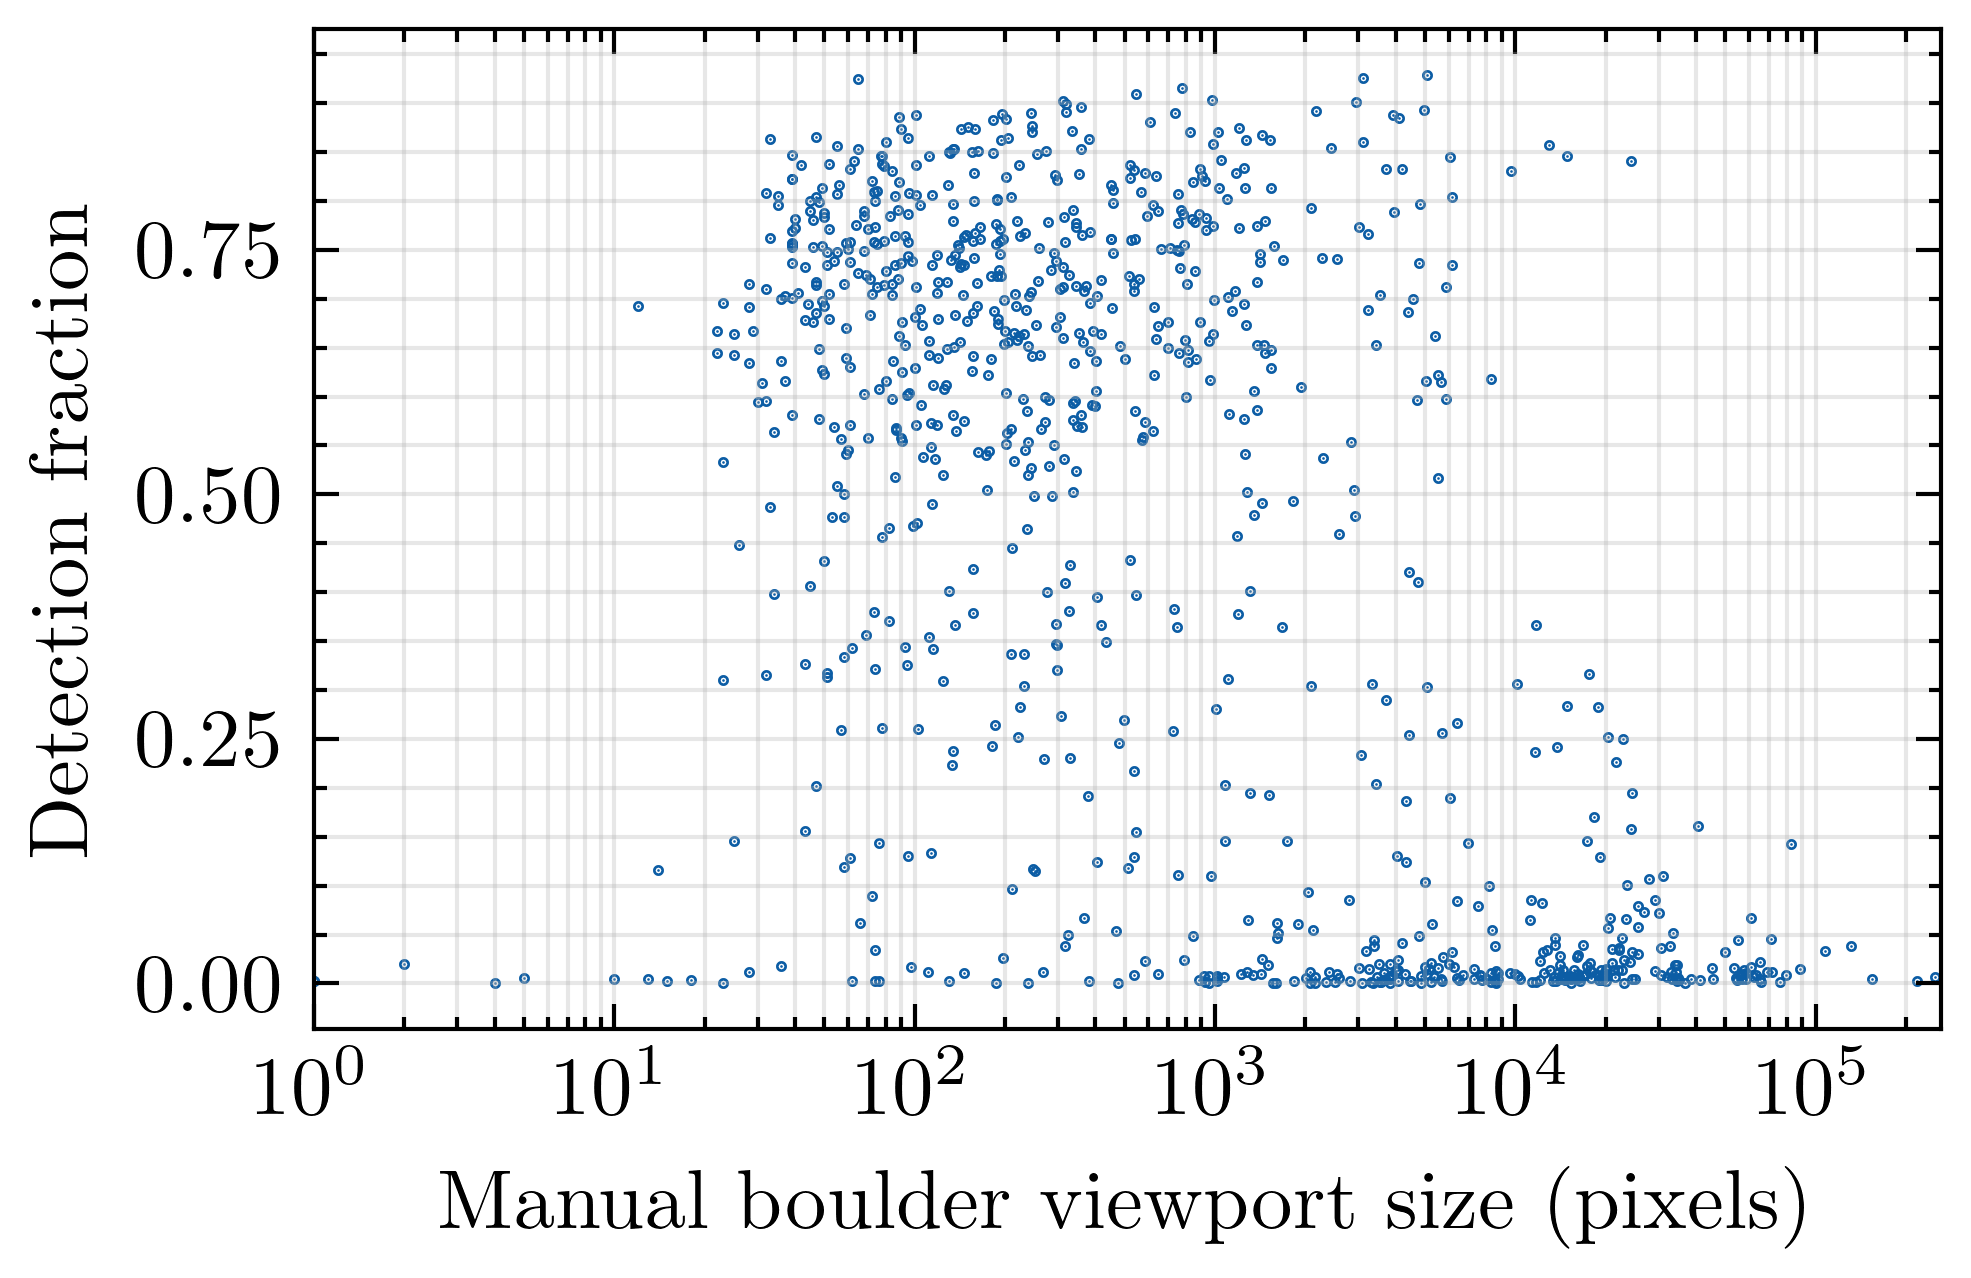

In [6]:
x = db_jaccard_agg["viewport_size"].to_numpy()
j = db_jaccard_agg["Jaccard_index"].to_numpy()

plt.scatter(x, j, s = 0.1)
plt.xscale("log")
# plt.ylim(0, 1.05)
plt.xlim(1, 512*512)
plt.xlabel("Manual boulder viewport size (pixels)")
plt.ylabel("Detection fraction")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()

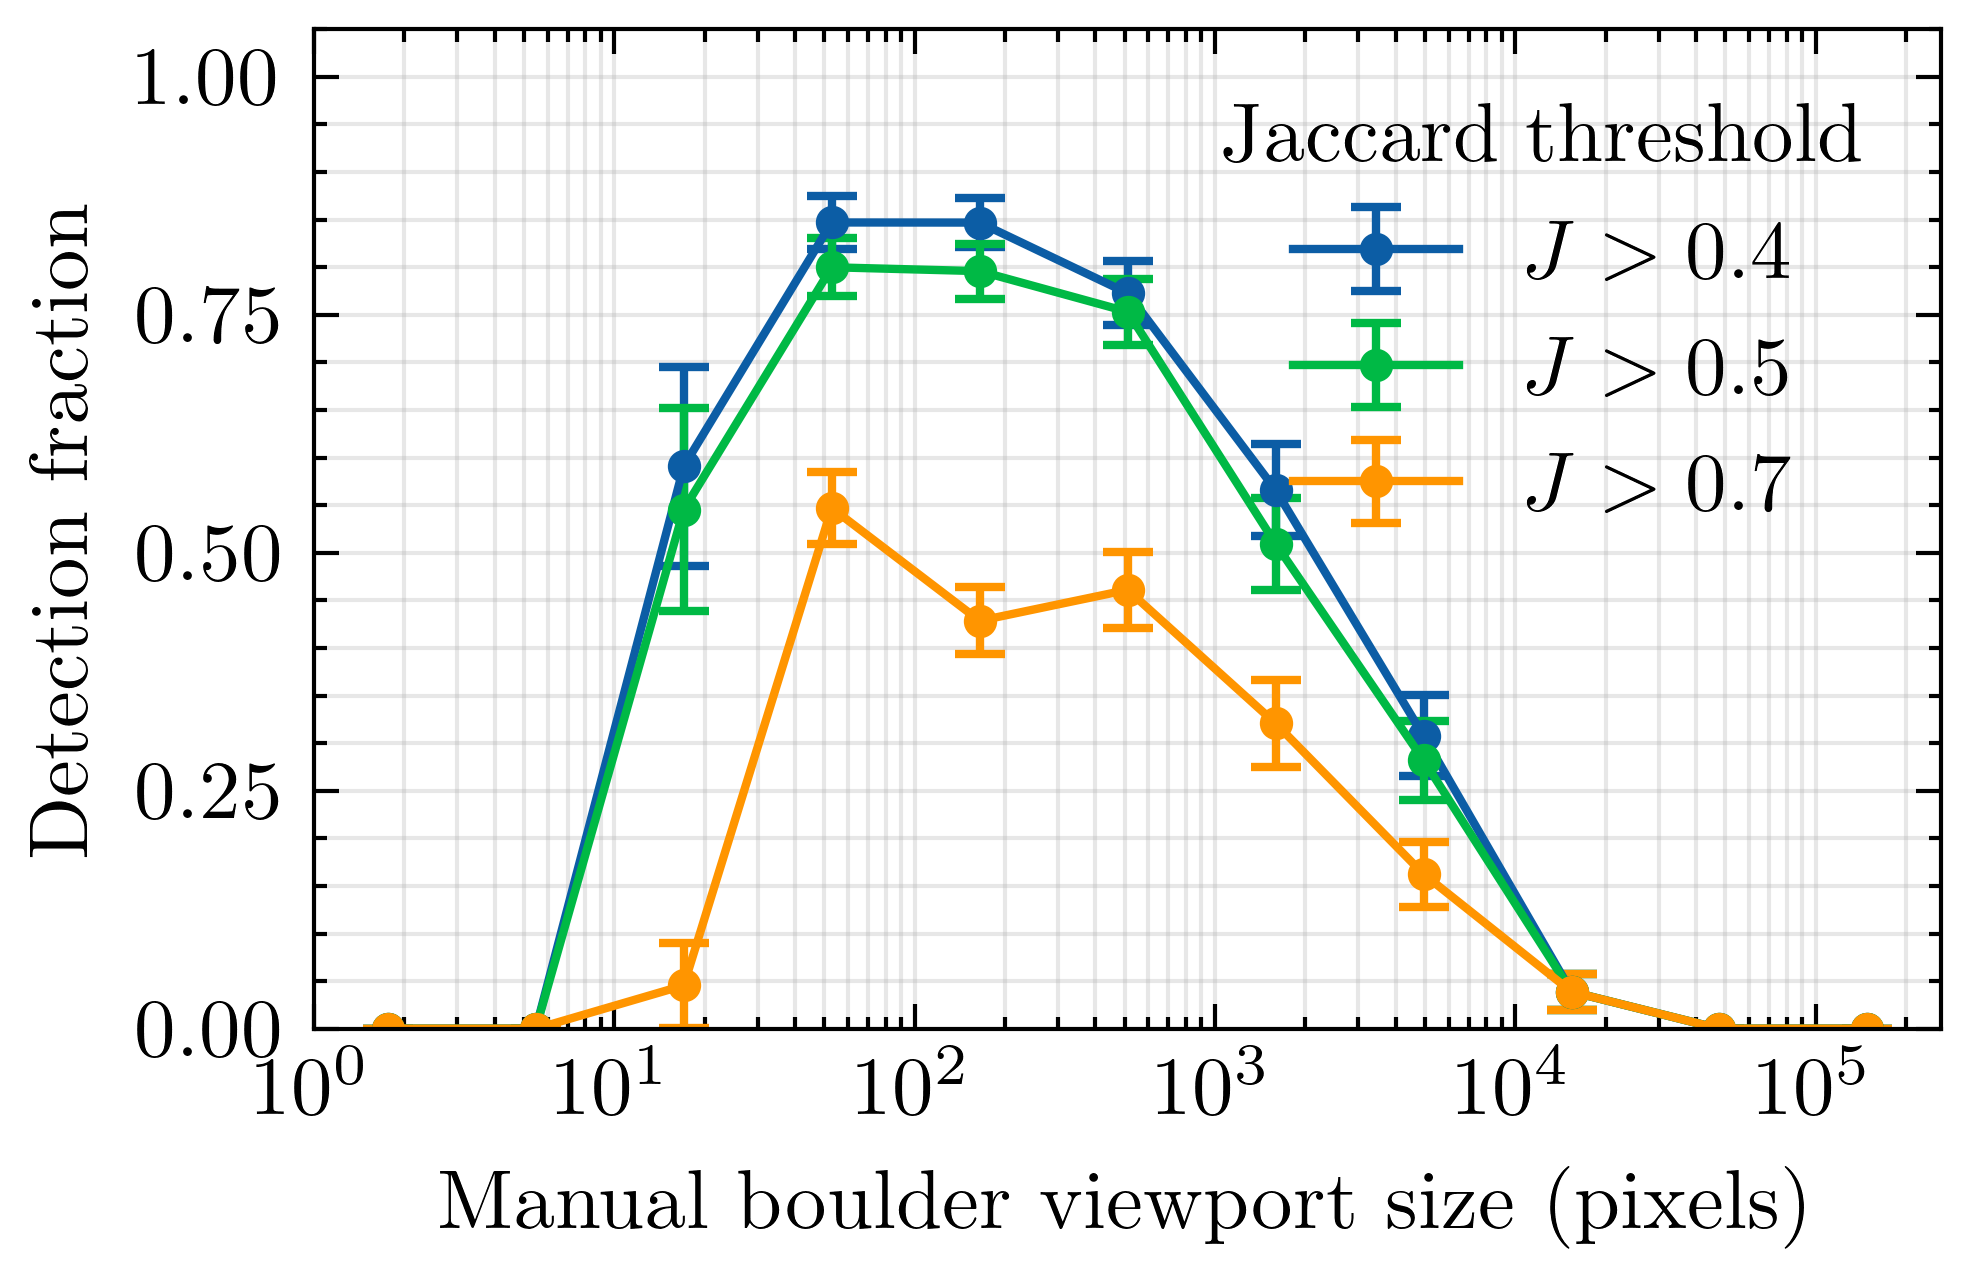

In [7]:
bins = np.geomspace(1, 512 * 512, 12)

centres = np.sqrt(bins[:-1] * bins[1:])

total, _ = np.histogram(x, bins=bins)

thresholds = [0.4, 0.5, 0.7]

# plt.figure(figsize=(8, 5))

for thresh in thresholds:
    success, _ = np.histogram(x[j > thresh], bins=bins)

    rate = np.divide(
        success,
        total,
        out=np.full_like(success, np.nan, dtype=float),
        where=total > 0,
    )

    err = np.sqrt(rate * (1 - rate) / total)
    err[total == 0] = np.nan

    plt.errorbar(
        centres,
        rate,
        yerr=err,
        marker=".",
        capsize=3,
        label=f"$J > {thresh}$",
    )

plt.xscale("log")
plt.ylim(0, 1.05)
plt.xlim(1, 512*512)
plt.xlabel("Manual boulder viewport size (pixels)")
plt.ylabel("Detection fraction")
plt.grid(True, which="both", alpha=0.3)
plt.legend(title="Jaccard threshold")
plt.savefig(".plots/S_from_manual_detection.png")
plt.show()


C:\Users\Joshu\AppData\Local\Temp\ipykernel_19704\3081111881.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(


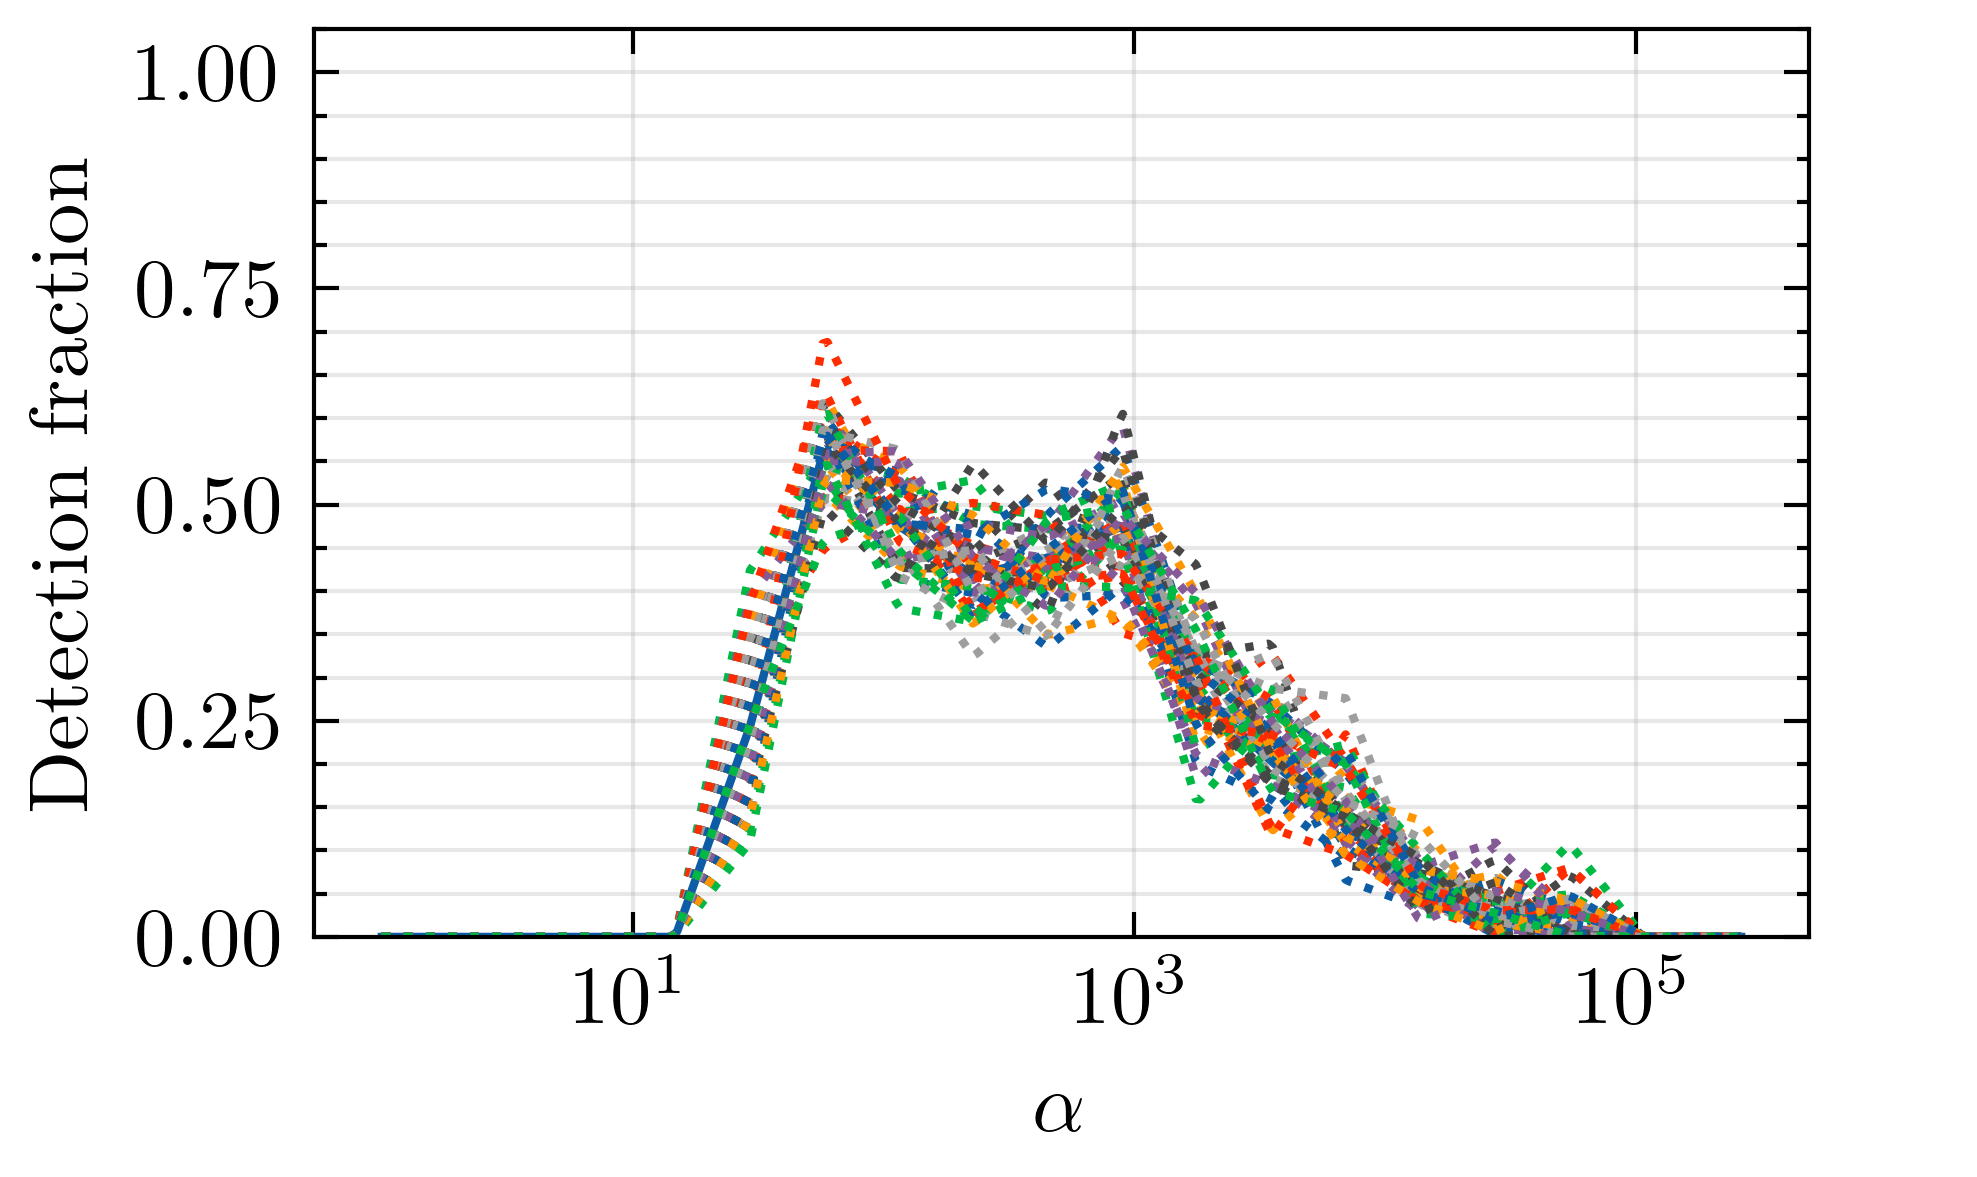

In [ ]:
from boulder_statistics.analysis.sensitivity_model import SensitivityModel
x_smooth = np.geomspace(1, 512 ** 2, 300)


sm = SensitivityModel(
        df = db_jaccard_agg,
        number_of_bins=16
    )

total_s = sm.best_p_function(x_smooth)

plt.plot(
    x_smooth,
    total_s,
    # label=r"$S(\alpha)$"
)

for i in range(50):
    rng = np.random.default_rng(i)
    plt.plot(
        x_smooth,
        sm.random_p_function(rng)(x_smooth),
        # label=r"$S(\alpha)$",
        ls = ":"
    )

plt.xscale("log")
# plt.xlim(1, 512*512)
plt.ylim(0, 1.05)
plt.xlabel(r"$\alpha$")
plt.ylabel("Detection fraction")
plt.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)
plt.tight_layout()
plt.grid(True, which="both", alpha=0.3)
# plt.savefig(".plots/S_alpha_vs_S_alpha_omega.png")
plt.show()

C:\Users\Joshu\AppData\Local\Temp\ipykernel_19704\2535500342.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(


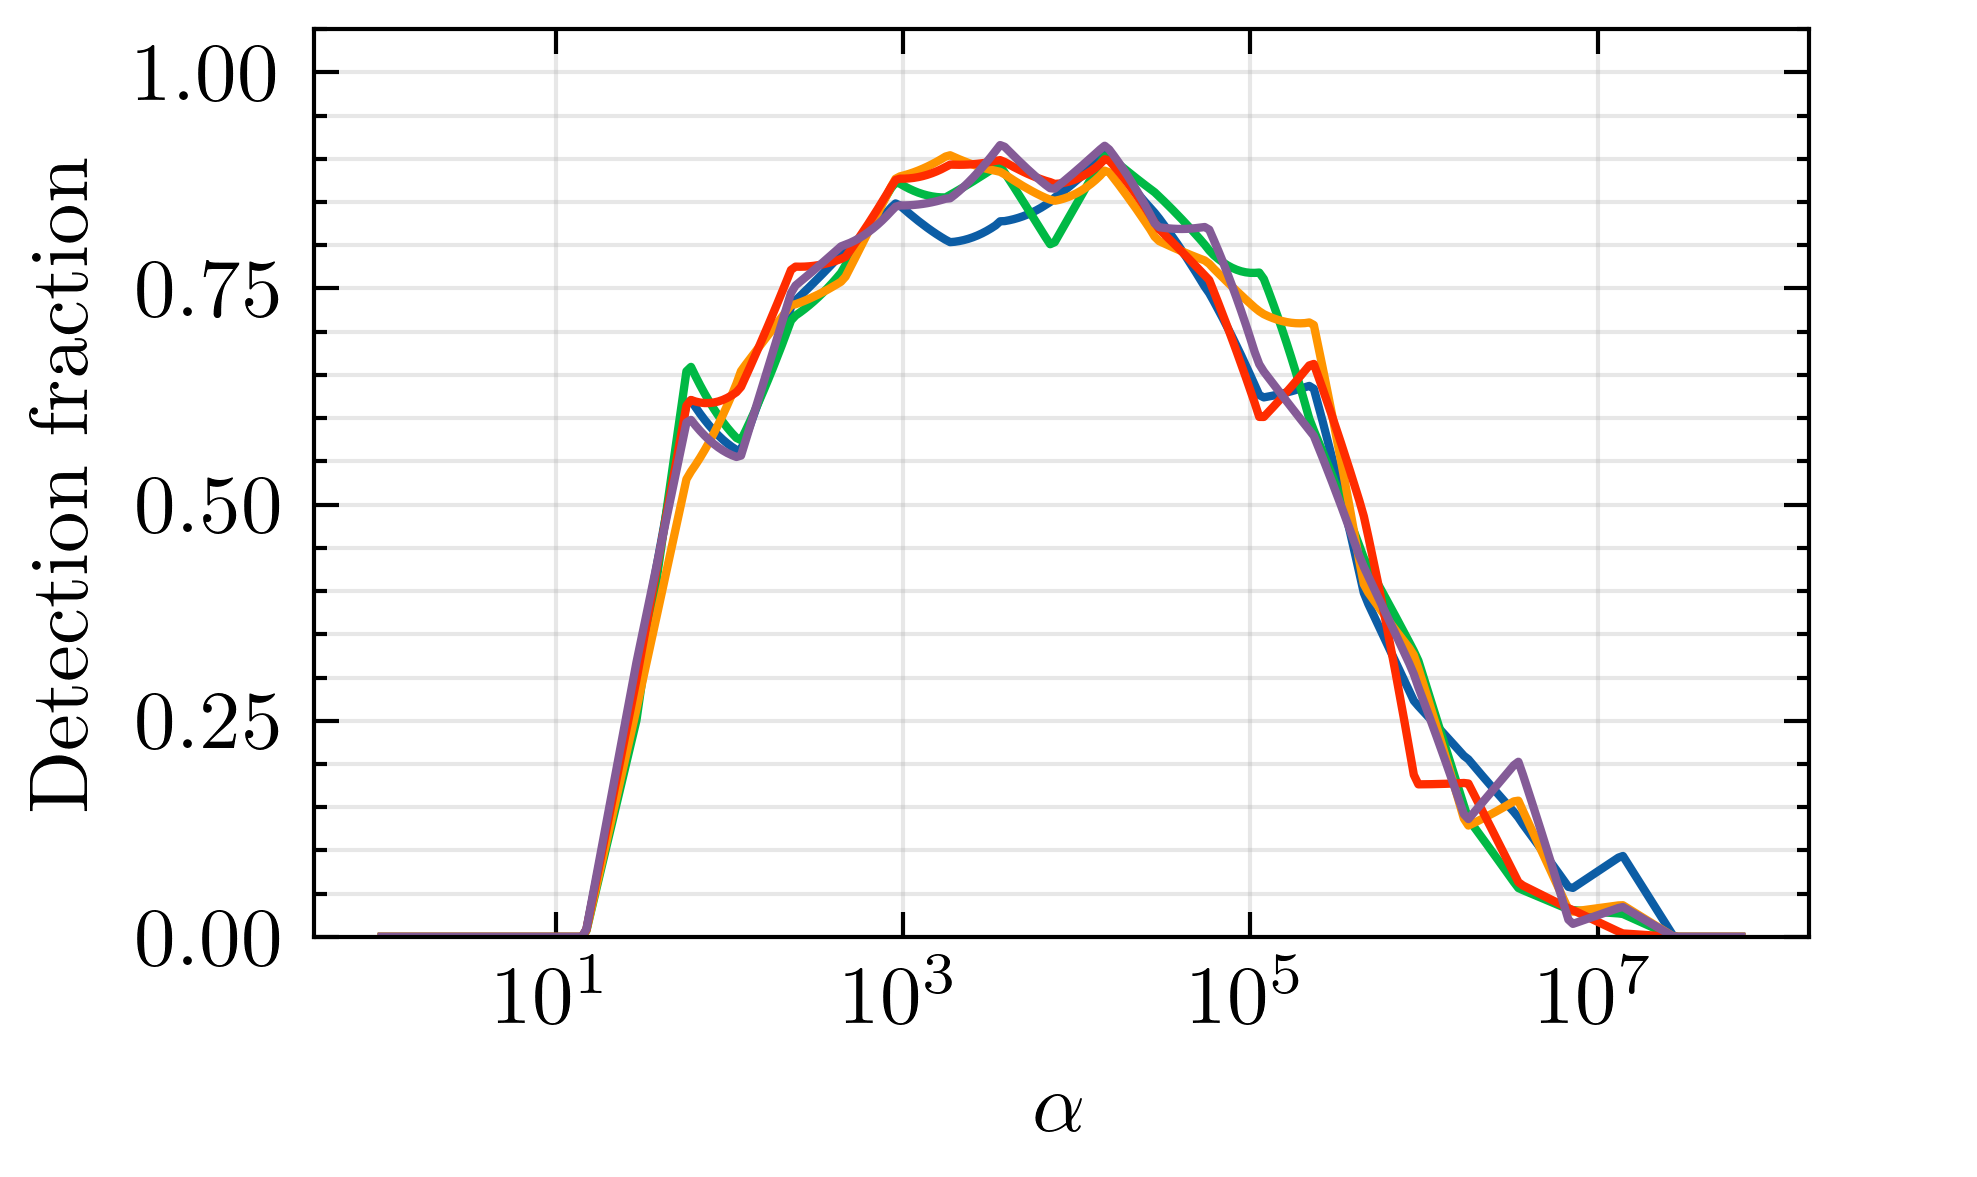

In [9]:
from boulder_statistics.analysis.sensitivity_model import SensitivityModel

for i in range(5):
    sm = SensitivityModel(
        df = db_jaccard_agg,
        number_of_bins=16
    )

    x_smooth = np.geomspace(1, ((512 ** 2) * 2 ** (2 * 4)), 300)

    # y_smooth = sm.best_p_function(x_smooth)
    # plt.plot(x_smooth, y_smooth, label=r"$S(\alpha|\omega_0)$", linestyle=":")
    # plt.scatter(centres, rate, color="C0", zorder=3, label="Bin centres")

    rng = np.random.default_rng(i)

    total_s = 1 - np.prod([
                1 - sm.random_p_function(rng)(x_smooth / (2 ** (2 * 4 - 2 * i))) for i in range(5)
            ], axis=0)

    plt.plot(
        x_smooth,
        total_s,
        # label=r"$S(\alpha)$"
    )

plt.xscale("log")
# plt.xlim(1, 512*512)
plt.ylim(0, 1.05)
plt.xlabel(r"$\alpha$")
plt.ylabel("Detection fraction")
plt.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)
plt.tight_layout()
plt.grid(True, which="both", alpha=0.3)
# plt.savefig(".plots/S_alpha_vs_S_alpha_omega.png")
plt.show()

In [10]:
db_jaccard_agg.write_parquet(r"C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33\.data_products\db_jaccard_agg.parquet")

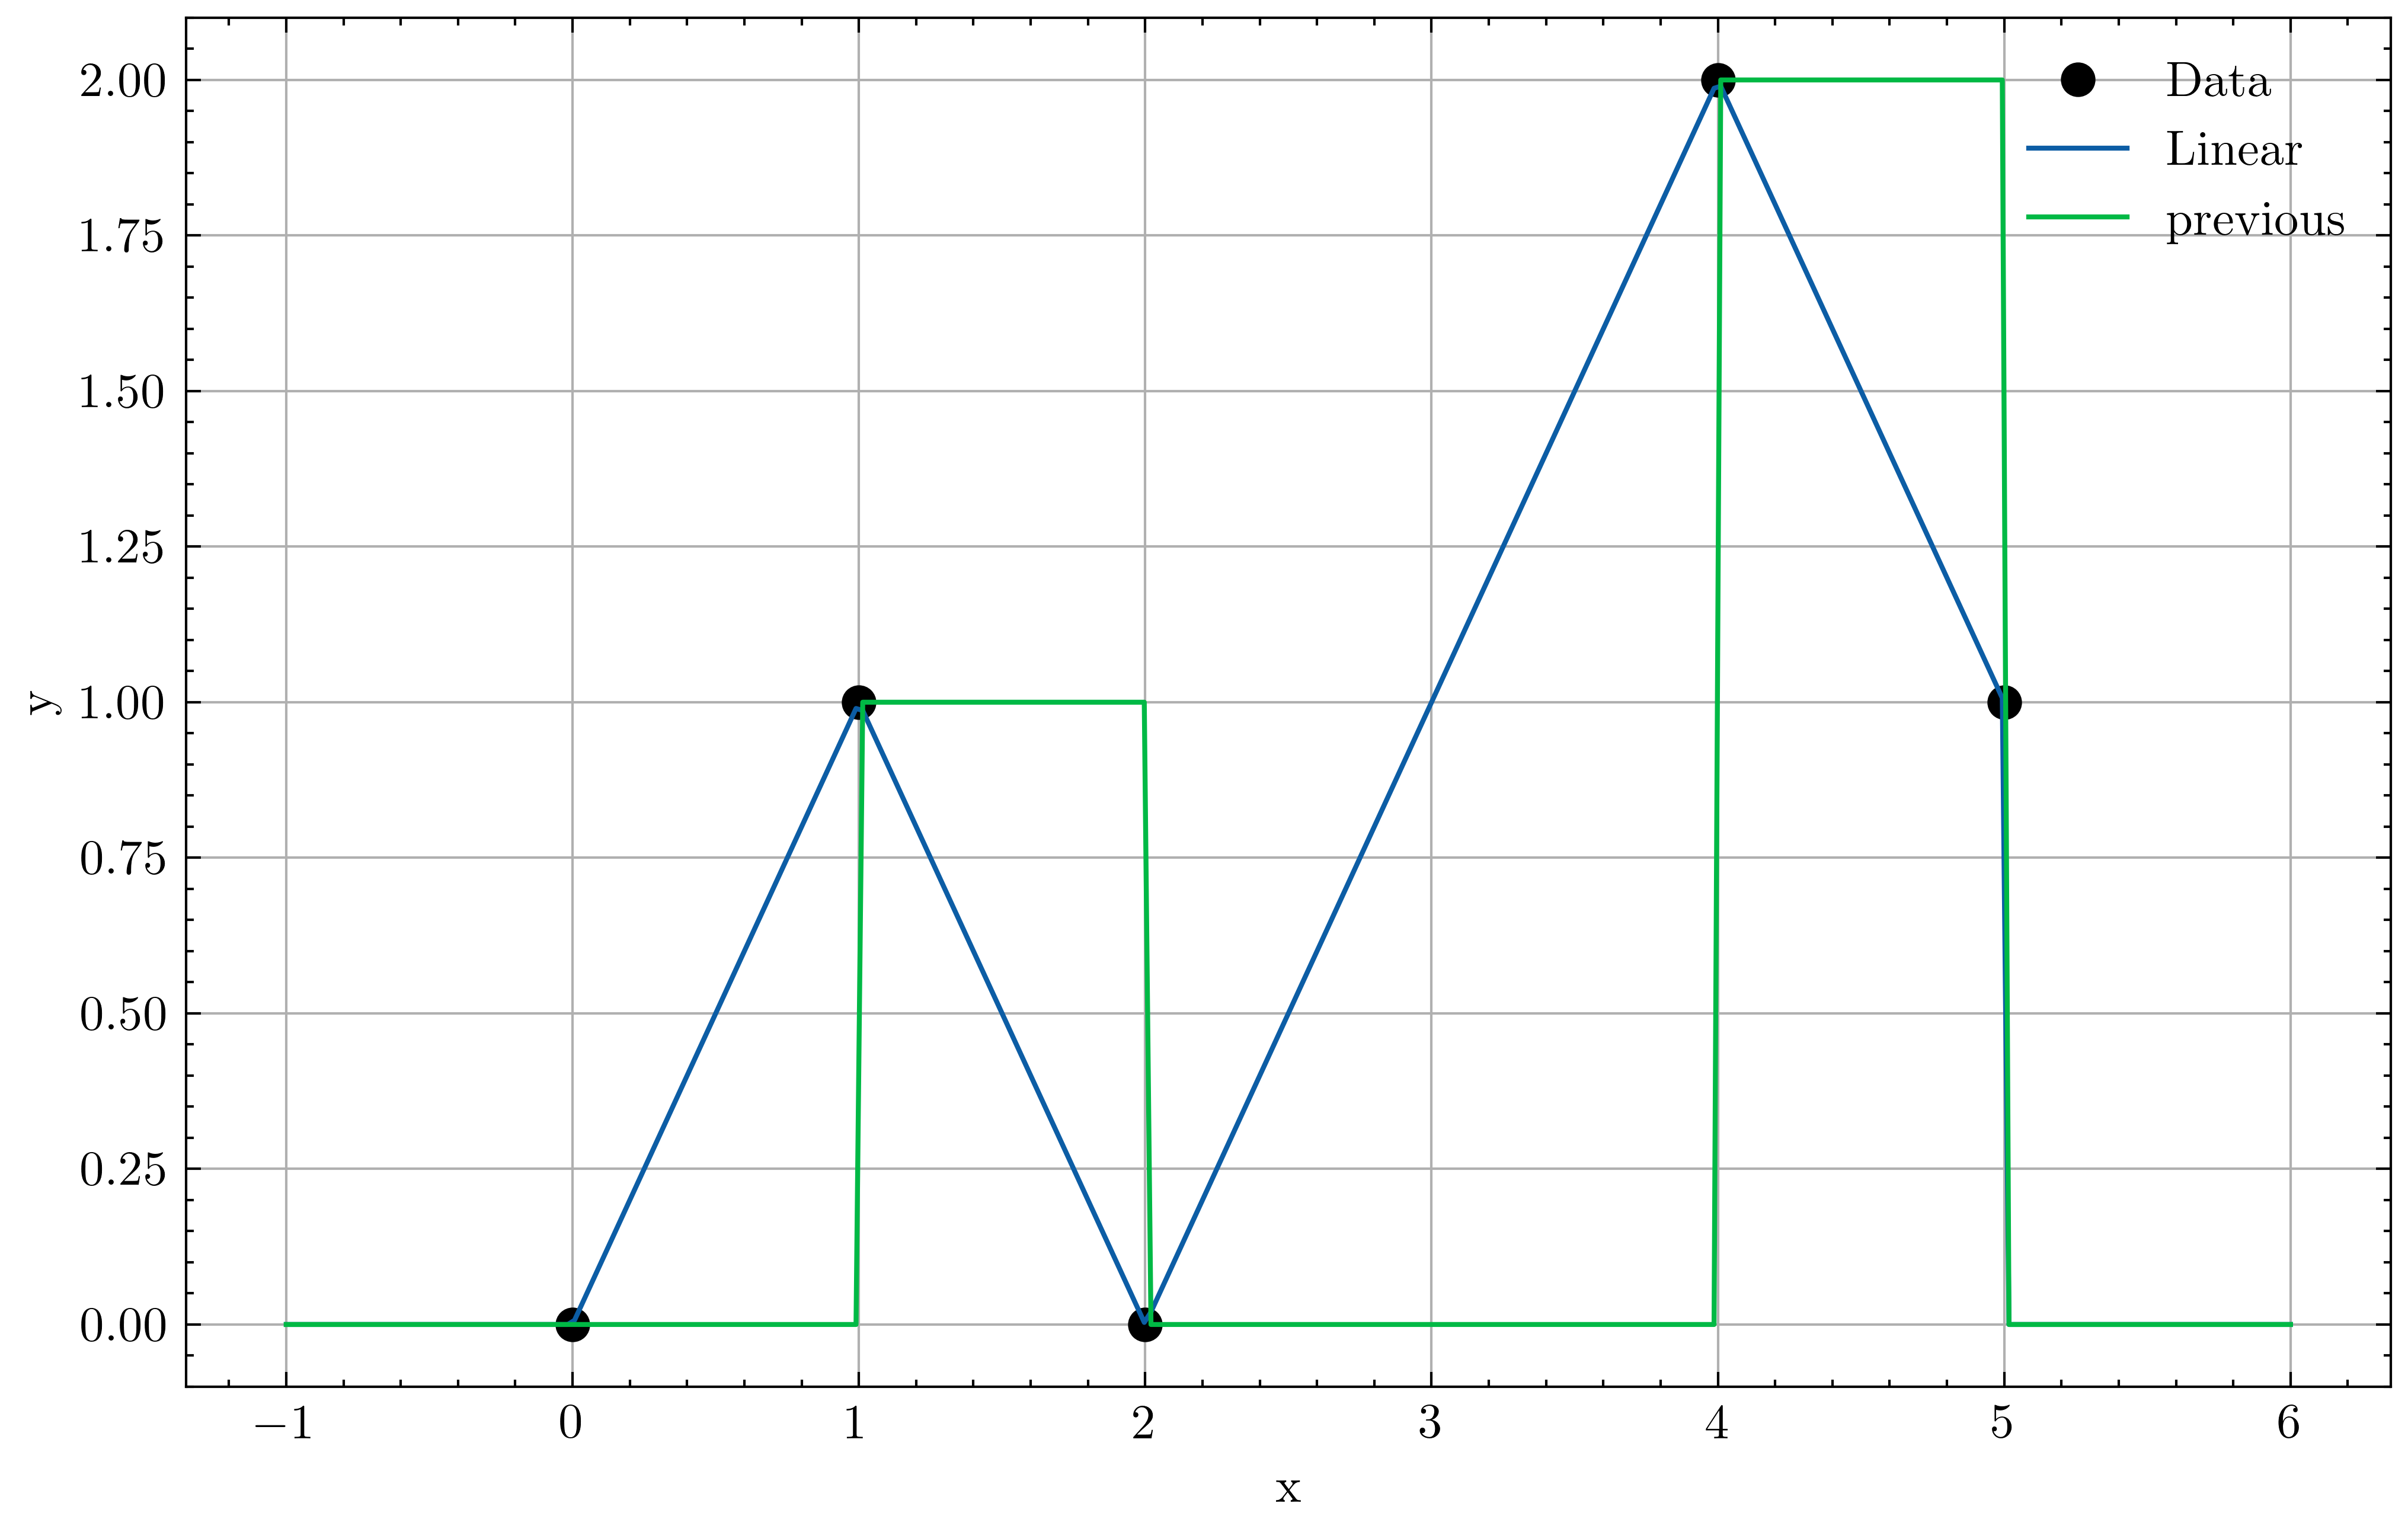

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# Original data
x = np.array([0, 1, 2, 4, 5])
y = np.array([0, 1, 0, 2, 1])

# Points where we want interpolated values
x_new = np.linspace(-1, 6, 300)

# Create interpolators
f_linear = interp1d(x, y, kind="linear", fill_value=0, bounds_error=False)
f_nearest = interp1d(x, y, kind="nearest", fill_value=0, bounds_error=False)
f_cubic = interp1d(x, y, kind="previous", fill_value=0, bounds_error=False)

# Evaluate
y_linear = f_linear(x_new)
y_nearest = f_nearest(x_new)
y_cubic = f_cubic(x_new)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(x, y, "ko", label="Data")
plt.plot(x_new, y_linear, label="Linear")
# plt.plot(x_new, y_nearest, label="Nearest")
plt.plot(x_new, y_cubic, label="previous")

plt.legend()
plt.grid(True)
plt.xlabel("x")
plt.ylabel("y")
plt.show()